In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, EllipticalAperture, EllipticalAnnulus
from astropy.nddata import Cutout2D
from matplotlib.patches import Ellipse
from astropy.table import Table, vstack, Column, unique

In [10]:
# Probably have them calculate surface brightness for their galaxy using the size and the magnitude they calculated before
# Then Ill give them a fits table of stars, their gmags from ASAS-SN, and their Petro radii or something
# Then have them calculate SB for that whole table
# Then have them plot g vs SB and see where galaxies lie compared to stars
# add errorbars

In [4]:
#The equation for surface brightness is: SB=m+2.5log(A)
#So calculate the surface brightness of your galaxy using the magnitude you found and the area you used
gal_m=17.418985214569332
A=9.5 * 7.8
B=6.2 * 7.8
a = A/2
b = B/2

gal_A=np.pi * (A/2) * (B/2)

gal_SB=gal_m+(2.5*np.log10(gal_A)) # magnitudes per arcseconds squared

print(gal_SB)

26.042471168404916


In [5]:
#At this point, Evan will give you a brief lecture on error propagation and together we will calculate the error on uncertainty

sigma_m=2.719310168247956
sigma_a=7.8
sigma_b=7.8

sigma_A= np.sqrt((np.pi*b*sigma_a)**2 + (np.pi*a*sigma_b)**2)

sigma_SB=np.sqrt((sigma_m)**2 + ((sigma_A * 2.5)/(gal_A * np.log(10)))**2)

print(gal_SB,' +/- ',sigma_SB)

26.042471168404916  +/-  2.7512835358796774


In [6]:
Star_Data=Table.read('Kamino_Star_Data.fits')
print(Star_Data)

      gmags              radii       
       mag                           
------------------ ------------------
 18.42687797452318 38.284271999999994
 18.99677797452318          28.549248
 18.99677797452318          28.549248
 16.23307797452318 30.193800000000003
 16.23307797452318 30.193800000000003
 17.62427797452318  61.83964799999999
17.234177974523178  77.84555999999999
 18.32297797452318 35.092200000000005
 17.75607797452318 60.169200000000004
               ...                ...
 17.60257797452318 33.742799999999995
16.993177974523178 39.666900000000005
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 13.99787797452318            40.7862
 17.26567797452318  70.60419599999999
 17.26567797452318  70.60419599999999
 19.03037797452318             28.119
 14.68977797452318 40.240199999999994
Length = 28612 rows


In [7]:
star_mags=Star_Data['gmags']
star_rads=Star_Data['radii']

star_SBs=star_mags+(2.5*np.log10(np.pi*star_rads*star_rads))

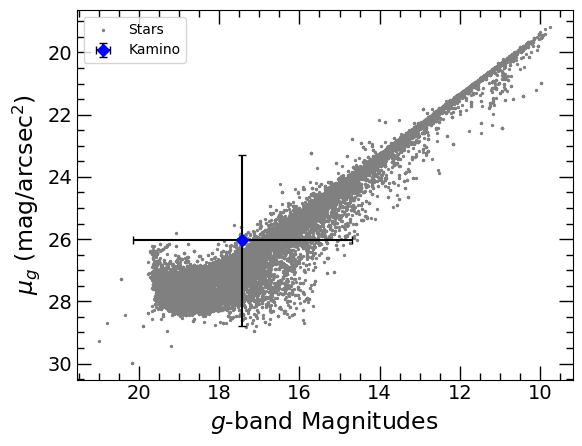

In [17]:
plt.scatter(star_mags,star_SBs, color='grey', s=2, label="Stars")
# plt.scatter(gal_m,gal_SB, color='blue', s=20, marker='D')
plt.errorbar(gal_m,gal_SB, yerr=sigma_SB, xerr=sigma_m, fmt='D', color='blue', ecolor='black', capsize=3, label="Kamino")

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

#Add x and y axes!
plt.xlabel(r"$g$-band Magnitudes", fontsize=17)
plt.ylabel(r"$\mu_g$ (mag/arcsec$^2$)", fontsize=17)
plt.minorticks_on()
plt.tick_params(which='both',direction="in", right=True, top=True)
plt.tick_params(which='major',direction="in", right=True, top=True, length=10, width=1, labelsize=14)
plt.tick_params(which='minor',direction="in", right=True, top=True, length=5, width=1)

plt.legend()

In [ ]:
# sigma_SB=np.sqrt((sigma_m**2)+((2.5/np.log(10))*(sigma_A/gal_A)))